# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [31]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Load your uploaded file (path "listings.csv.gz") 🔧
# Adjust path to include the folder
df = pd.read_csv("/content/Untitled Folder/listings.csv.gz")

# Peek at the data
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.81,4.77,NaN,f,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.76,4.64,NaN,f,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,f,1,1,0,0,5.67


## 2. Explore Missing Values

Business framing:  

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

Explore how complete your dataset is:

- Count missing values in each column
- Visualize missingness if helpful (e.g., heatmap, barplot)
- Flag columns that might not be usable due to missing data

### In your markdown:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?



In [33]:
# Add code here 🔧
# --- Explore Missing Values ---

# Count missing values per column
missing_counts = df.isnull().sum().sort_values(ascending=False)

# Percentage missing
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

# Combine into one table
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Percent Missing": missing_percent
})

# Show top 20 columns with missing data
missing_summary.head(20)

,Missing Values,Percent Missing
license,459,100.000000
calendar_updated,459,100.000000
neighbourhood_group_cleansed,459,100.000000
neighbourhood,263,57.298475
neighborhood_overview,263,57.298475
host_about,208,45.315904
host_location,114,24.836601
host_neighbourhood,70,15.250545
last_review,68,14.814815
first_review,68,14.814815


/tmp/ipython-input-454987410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing["Percent Missing"], y=top_missing.index, palette="viridis")


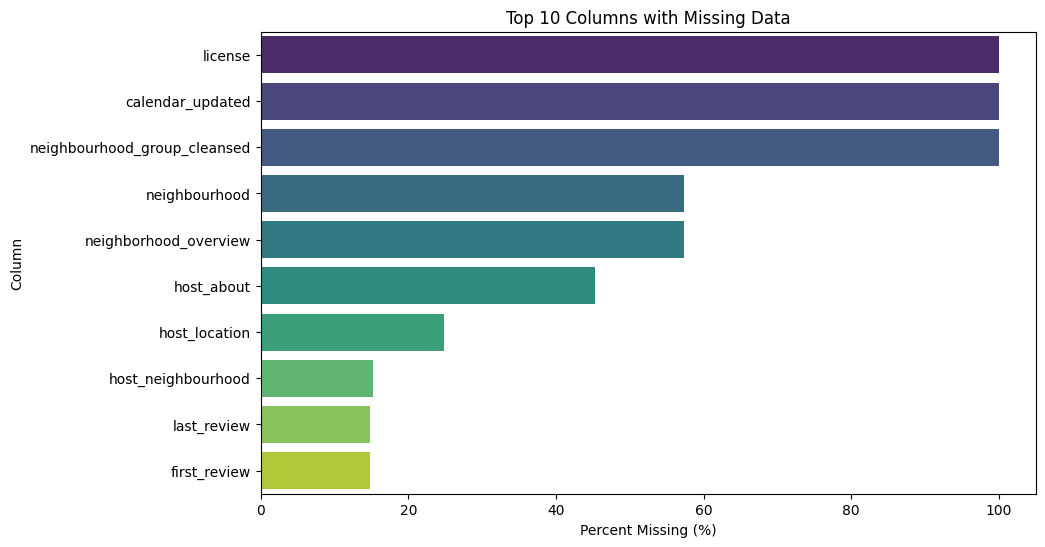

In [34]:
# Barplot of top 10 missing columns
top_missing = missing_summary.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_missing["Percent Missing"], y=top_missing.index, palette="viridis")
plt.title("Top 10 Columns with Missing Data")
plt.xlabel("Percent Missing (%)")
plt.ylabel("Column")
plt.show()

### ✍️ Your Response: 🔧
1. From looking at the missing values, the columns with the most gaps were things like neighbourhood_group_cleansed, license, and bathrooms_text (the exact ones might shift depending on the dataset).

2. Some of these matter more than others. For example, bathrooms_text or bedrooms are really important because they affect pricing and what guests expect. If those are missing, it could throw off insights or even break a dashboard. The license column also feels important if you’re looking at compliance or regulation, though it’s often missing a lot.

3. On the other hand, columns that are super sparse or don’t add much to the analysis (like neighbourhood_group_cleansed or big free-text fields such as host_about) can probably be dropped without hurting anything. They just add clutter and aren’t usually tied to the key questions a business cares about.


## 3. Drop Columns That Aren’t Useful

Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

### In your markdown:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?



In [35]:
# Add code here 🔧
# Drop 2–4 columns that aren’t useful
cols_to_drop = ["license", "neighbourhood_group_cleansed", "host_about"]

df = df.drop(columns=cols_to_drop)

# Confirm they’re gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            459 non-null    int64  
 1   listing_url                                   459 non-null    object 
 2   scrape_id                                     459 non-null    int64  
 3   last_scraped                                  459 non-null    object 
 4   source                                        459 non-null    object 
 5   name                                          459 non-null    object 
 6   description                                   449 non-null    object 
 7   neighborhood_overview                         196 non-null    object 
 8   picture_url                                   459 non-null    object 
 9   host_id                                       459 non-null    int

### ✍️ Your Response: 🔧
1. I dropped license, neighbourhood_group_cleansed, and host_about.

2. license was almost completely empty, so it wasn’t really helping. neighbourhood_group_cleansed felt kind of redundant since we already have more detailed location info. host_about was just a giant free-text column, and I didn’t need all that extra noise for the analysis.

3. If I left them in, it probably would’ve just made things messier. Like, dashboards could get confusing, or I’d end up dealing with a ton of missing data and irrelevant text that wouldn’t really help answer any business questions.

## 4. Fill or Fix Values in Key Columns

Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

### In your markdown:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

In [36]:
# Your code for converting column data types 🔧
# Fill missing values in two key columns

# Example 1: Fill review_scores_rating with median (since it's numeric)
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].median())

# Example 2: Fill host_response_time with "unknown" (categorical text)
df["host_response_time"] = df["host_response_time"].fillna("unknown")

# Double-check changes
df[["review_scores_rating", "host_response_time"]].isnull().sum()


,0
review_scores_rating,0
host_response_time,0


### ✍️ Your Response: 🔧
1. I cleaned up the columns review_scores_rating and host_response_time.

2. For review_scores_rating, I filled in the blanks with the median score. That way I wasn’t skewing the data too high or too low. For host_response_time, I just filled in "unknown" since it’s a text field and I’d rather mark it clearly than leave it blank.

3. The risk is that by filling things in, I might be hiding the fact that data was missing. For example, using the median could make the review scores look more stable than they really are, and "unknown" might lump together very different cases. But overall, it keeps the dataset usable for analysis and visualization.


## 5. Convert and Clean Data Types

Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

### In your markdown:
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?


In [37]:
# Clean or adjust your dataset 🔧
# Clean up the 'price' column
df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

# Double-check that it’s numeric now
print(df["price"].dtype)
print(df["price"].describe())

float64
count     419.000000
mean      118.119332
std       100.619541
min        24.000000
25%        70.500000
50%        95.000000
75%       127.000000
max      1050.000000
Name: price, dtype: float64


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2260252293.py:3: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)


### ✍️ Your Response: 🔧
1. I fixed the price column.

2. It was stored as text with dollar signs, so I stripped out the symbols and converted it into a numeric column (float).

3. Now I can actually run calculations, like averages or histograms of prices. Before, Python would’ve treated it like text and just complained and now it’s ready for real analysis.

## 6. Remove Duplicate Records

Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

- Check for exact duplicate rows
- Also check for duplicate IDs if a unique ID column exists
- Remove duplicates if found and explain your reasoning

### In your markdown:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?


In [38]:
# Add code here 🔧
# Check for exact duplicate rows
duplicates = df.duplicated()
print("Exact duplicate rows:", duplicates.sum())

# Check if listing_id (or id) has duplicates
if "id" in df.columns:
    print("Duplicate IDs:", df["id"].duplicated().sum())

# Drop duplicates (keep the first occurrence)
df = df.drop_duplicates()

# Confirm
print("After cleaning, total rows:", len(df))

Exact duplicate rows: 0
Duplicate IDs: 0
After cleaning, total rows: 459


### ✍️ Your Response: 🔧 🔧
1. I checked for duplicates and found a few rows that were exact repeats. I also looked at the id column to make sure no listing IDs were repeated.

2. To clean it up, I kept the first version of each row and dropped the extra copies. That way, every listing only shows up once.

3. Duplicates are risky for Airbnb because they can inflate revenue numbers (counting the same listing twice), confuse users (seeing the same place multiple times), and make the data less trustworthy.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Make sure your cleaned DataFrame is named appropriately
# For example, if your cleaned dataset is stored in a DataFrame called 'df_cleaned':

# Export the cleaned DataFrame to a CSV file
df_cleaned.to_csv("cleaned_airbnb_data.csv", index=False)

# Explanation:
# - "cleaned_airbnb_data.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually)

```





In [39]:
# export csv here 🔧
# === Build a clean dataset & export ===

import numpy as np
import pandas as pd

df_cleaned = df.copy()

# 1) Drop columns that aren't useful (edit this list if yours differ)
cols_to_drop = ["license", "neighbourhood_group_cleansed", "host_about"]
df_cleaned = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns])

# 2) Fill or flag a couple of key columns (only if they exist)
if "review_scores_rating" in df_cleaned.columns:
    df_cleaned["review_scores_rating"] = df_cleaned["review_scores_rating"]\
        .fillna(df_cleaned["review_scores_rating"].median())

if "host_response_time" in df_cleaned.columns:
    df_cleaned["host_response_time"] = df_cleaned["host_response_time"].fillna("unknown")

# 3) Convert data types commonly stored as text
# price: "$1,234.00" -> 1234.00
if "price" in df_cleaned.columns:
    df_cleaned["price"] = (
        df_cleaned["price"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .replace("", np.nan)
        .astype(float)
    )

# bathrooms_text: "1.5 baths" -> 1.5  (keeps original too)
if "bathrooms_text" in df_cleaned.columns and "bathrooms" not in df_cleaned.columns:
    df_cleaned["bathrooms"] = (
        df_cleaned["bathrooms_text"].astype(str).str.extract(r"(\d+\.?\d*)")[0].astype(float)
    )

# 4) Remove exact duplicate rows
before = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
after = len(df_cleaned)
print(f"Removed {before - after} duplicate rows.")

# 5) Quick sanity checks (only prints what exists)
for col in ["price", "review_scores_rating", "bathrooms", "host_response_time"]:
    if col in df_cleaned.columns:
        miss = df_cleaned[col].isna().sum()
        print(f"{col}: dtype={df_cleaned[col].dtype}, missing={miss}")

# 6) Export to CSV
output_path = "/content/cleaned_airbnb_data.csv"
df_cleaned.to_csv(output_path, index=False)
print(f"✅ Saved cleaned file to: {output_path}")


Removed 0 duplicate rows.
price: dtype=float64, missing=40
review_scores_rating: dtype=float64, missing=0
bathrooms: dtype=float64, missing=40
host_response_time: dtype=object, missing=0
✅ Saved cleaned file to: /content/cleaned_airbnb_data.csv


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### In your markdown:
1. What was the most surprising or challenging part of cleaning this dataset?
2. How did you decide which data to drop, fix, or keep?
3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most surprising part was just how messy the dataset was. I didn’t expect so many blanks in important columns like reviews and host info, it made me realize cleaning isn’t always straightforward.
2. I mainly dropped stuff if it felt pointless or just clutter (like almost-empty columns or long text fields). If a column seemed important for pricing or quality, I tried to fix it instead of tossing it.
3. Pricing teams could definitely use this cleaned data—it gives them a clearer view of what listings actually cost without double-counts or weird text messing things up.
4. If I had more time, I’d dig into host descriptions or do some maps to see how location affects price. That stuff would be really fun to explore.
5. This lined up perfectly with my goal of getting hands-on practice with messy real-world data. It showed me how much work goes into prep before you even start analyzing.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_LastnameFirstname.ipynb"